In [8]:
#Load libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer
from matplotlib import pyplot as plt

In [9]:
FUNCTIONS_HOME = '../../../functions/evaluation_functions/' #home directory of the project
REAL_DATA_HOME = '../../../data/raw/chap/' #home directory of the project
SYN_DATA_HOME  = '../../../data/processed/chap/' #home directory of the project
TRAIN_FILE = '1_Chap_Data_Real_Train.csv'
SYNTHETIC_FILE = '1_Chap_Data_Synthetic_SDV.csv'

## 1. Read data

In [10]:
real_data = pd.read_csv(REAL_DATA_HOME + TRAIN_FILE)
categorical_columns = ['group']
categorical_columns
for col in categorical_columns :
    real_data[col] = real_data[col].astype('category')
data_train = real_data
real_data

,group,sbp1,sbp2,sbp3,sbp4,dbp1,dbp2,dbp3,dbp4
0,Group0,2.009493,0.084640,-0.020160,0.107037,0.857051,-0.048580,0.141517,0.137274
1,Group0,1.647881,0.285048,0.750705,-0.365256,0.594206,-0.094862,0.201428,-0.240859
2,Group0,0.045838,-0.301003,-0.007641,0.189160,1.875668,-0.152879,0.003445,0.012916
3,Group0,-1.626382,0.438629,-0.352224,-0.147169,-2.445341,0.362086,-0.132354,-0.016382
4,Group0,-0.244556,-0.781058,0.191160,0.637441,-2.766078,-1.110363,0.746589,0.140332
...,...,...,...,...,...,...,...,...,...
2712,Group0,0.048656,0.340805,0.146978,-0.077990,1.468295,-0.105885,0.037067,-0.001841
2713,Group0,-3.007362,-0.110868,-0.547719,-0.061449,-3.286850,-0.079093,-0.126217,0.165070
2714,Group0,0.481546,-0.118290,-0.159216,-0.046665,0.013795,0.235801,-0.128855,0.206748
2715,Group0,0.199530,0.371273,0.268324,0.670192,0.275167,-0.382674,0.076358,0.294886


In [11]:
real_data.dtypes

group    category
sbp1      float64
sbp2      float64
sbp3      float64
sbp4      float64
dbp1      float64
dbp2      float64
dbp3      float64
dbp4      float64
dtype: object

### 1.1. Create metada

In [12]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)
metadata

{
    "columns": {
        "group": {
            "sdtype": "categorical"
        },
        "sbp1": {
            "sdtype": "numerical"
        },
        "sbp2": {
            "sdtype": "numerical"
        },
        "sbp3": {
            "sdtype": "numerical"
        },
        "sbp4": {
            "sdtype": "numerical"
        },
        "dbp1": {
            "sdtype": "numerical"
        },
        "dbp2": {
            "sdtype": "numerical"
        },
        "dbp3": {
            "sdtype": "numerical"
        },
        "dbp4": {
            "sdtype": "numerical"
        }
    },
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1"
}

## 2. Train the model and generate data

In [14]:
# 3. 创建synthesizer并训练
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(real_data)

In [15]:
synthetic_data = synthesizer.sample(num_rows=len(real_data))
synthetic_data

,group,sbp1,sbp2,sbp3,sbp4,dbp1,dbp2,dbp3,dbp4
0,Group0,0.636626,0.196489,0.580205,0.260716,-0.141685,-0.940402,0.478726,0.089044
1,Group0,-3.663480,-0.576449,-0.036454,-0.365500,-1.418683,0.268234,-0.119606,-0.341160
2,Group0,-2.290469,-0.959807,-0.078261,0.315556,0.102967,-0.569566,-0.385519,-0.124791
3,Group0,1.039903,0.654351,-0.537303,0.108847,4.651015,0.032991,-0.121340,0.216337
4,Group0,2.772303,0.458008,-0.591914,0.025155,-3.196961,0.279064,-0.365028,0.306224
...,...,...,...,...,...,...,...,...,...
2712,Group0,2.498367,-0.237746,-0.204875,-0.199771,-1.730213,0.819302,-0.061461,-0.030586
2713,Group0,3.619119,1.925700,-0.673044,0.158926,5.919626,0.635406,-0.143706,0.311389
2714,Group0,-6.744096,0.678333,-0.666009,0.263141,-3.587673,-0.283128,0.356059,0.222930
2715,Group0,-0.396708,-0.782045,0.437572,0.035828,-0.962446,0.931447,-0.230310,-0.120290


In [16]:
real_data.describe()

,sbp1,sbp2,sbp3,sbp4,dbp1,dbp2,dbp3,dbp4
count,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000
mean,0.072962,-0.015681,0.030675,0.038696,0.057982,-0.056777,0.022021,0.028471
std,4.086347,0.729714,0.509026,0.262684,3.710970,0.733119,0.371803,0.180631
min,-18.884976,-2.732794,-2.023219,-1.289887,-17.202625,-2.580206,-1.409579,-0.862115
25%,-2.674316,-0.470025,-0.306902,-0.126936,-2.352459,-0.519699,-0.224223,-0.085791
50%,0.301318,-0.016234,0.026003,0.034561,0.244464,-0.044513,0.016090,0.032382
75%,2.979693,0.441029,0.354509,0.202381,2.653050,0.436457,0.258646,0.144028
max,11.023203,3.680704,2.233565,1.292367,12.307994,2.916243,1.550258,0.852724


In [17]:
synthetic_data.describe()

,sbp1,sbp2,sbp3,sbp4,dbp1,dbp2,dbp3,dbp4
count,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000,2717.000000
mean,0.043389,-0.052690,0.037121,0.044507,0.094969,-0.065455,0.026110,0.027578
std,4.061059,0.743950,0.502138,0.266170,3.806320,0.737452,0.373831,0.182647
min,-12.486401,-2.320734,-1.778231,-0.819853,-10.877722,-2.430142,-1.307214,-0.525000
25%,-2.693200,-0.568756,-0.301537,-0.128449,-2.492680,-0.558914,-0.235107,-0.096274
50%,0.250448,-0.050443,0.050617,0.048493,0.093386,-0.061280,0.025117,0.029375
75%,2.885994,0.460653,0.371703,0.218779,2.695130,0.420976,0.272017,0.153044
max,11.023203,1.992249,1.826507,0.853115,12.307994,2.916243,1.357135,0.621789


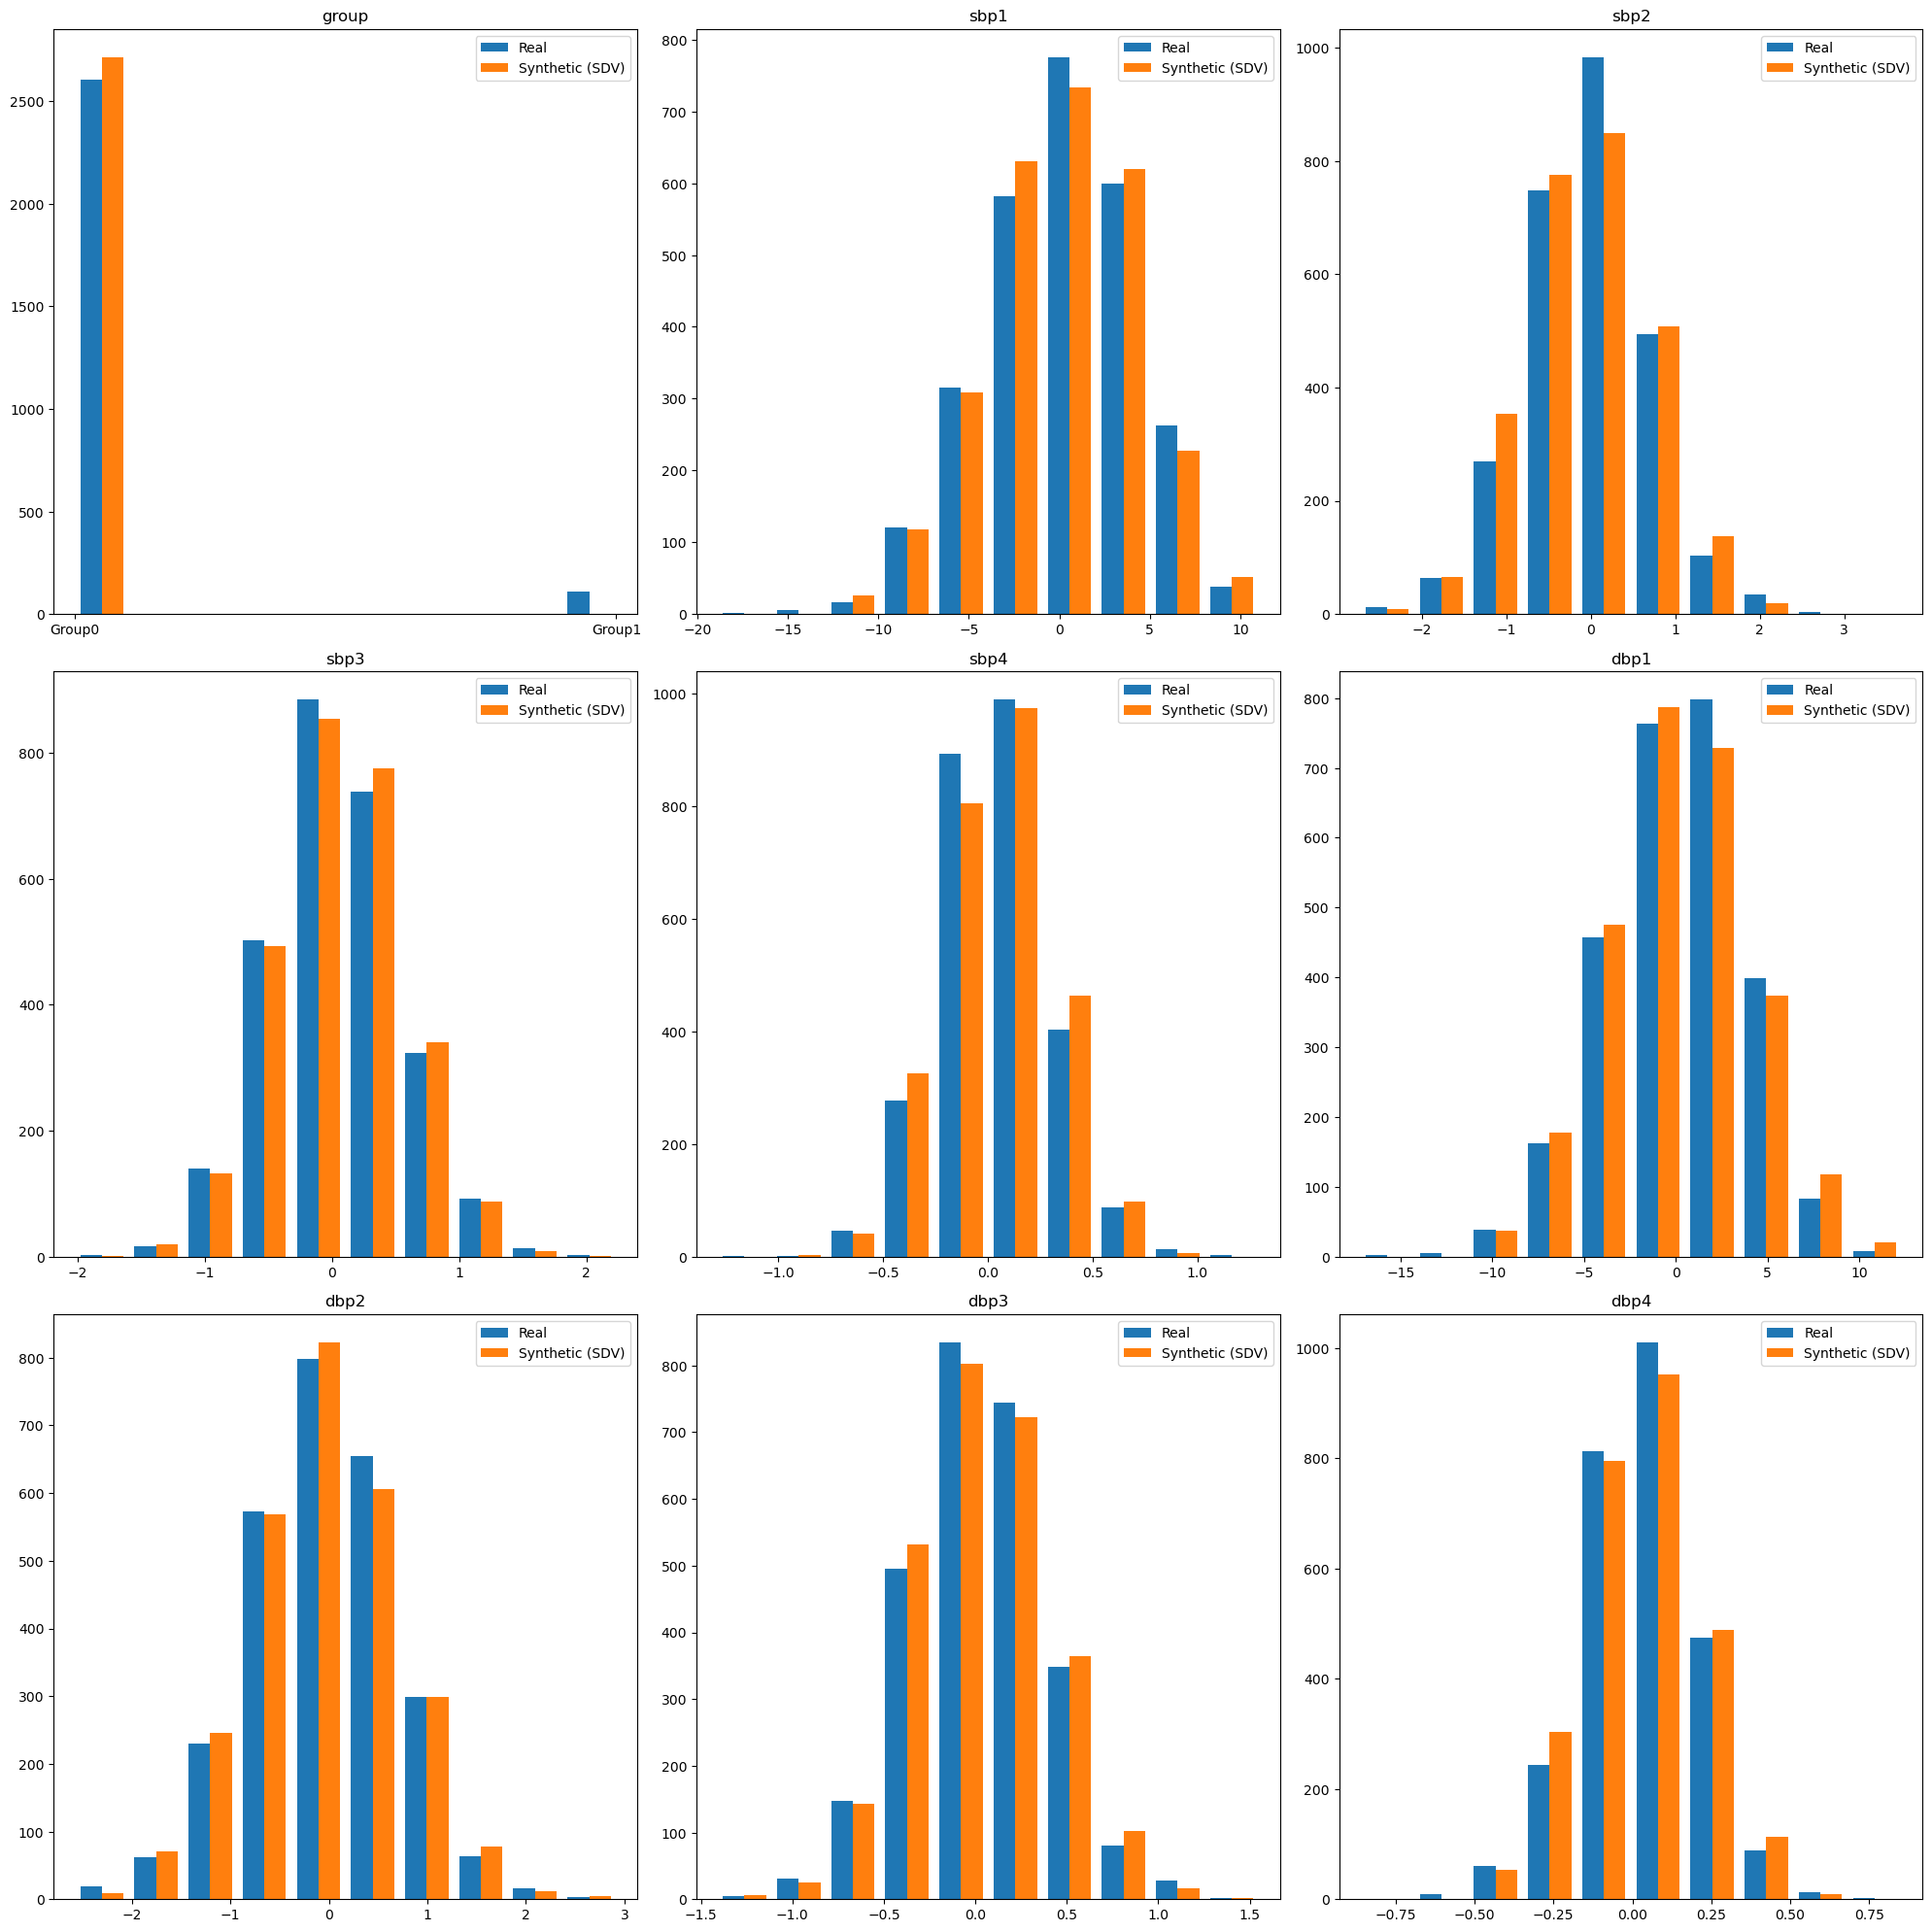

In [24]:
columns = real_data.columns
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20,20))
idx = {0:[0,0], 1:[0,1], 2:[0,2], 3:[1,0], 4:[1,1], 5:[1,2], 6:[2,0], 7:[2,1], 8:[2,2]}
for i in range(0,len(columns)) :
    data = np.column_stack((real_data[columns[i]], synthetic_data[columns[i]]))
    axs[idx[i][0], idx[i][1]].hist(data, density=False, histtype='bar', label=['Real','Synthetic (SDV)'])
    axs[idx[i][0], idx[i][1]].set_title(columns[i])
    axs[idx[i][0], idx[i][1]].legend()
# fig.delaxes(axs[3,2])
fig.tight_layout(pad=1.1)

In [22]:
synthetic_data.to_csv(SYN_DATA_HOME + SYNTHETIC_FILE, index = False)

In [23]:
SYNTHETIC_FILE

'SYNTHETIC DATASETS/SDV/1_Chap_Data_Synthetic_SDV.csv'